In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('data/titanic_train.csv')
df_test = pd.read_csv('data/titanic_test.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


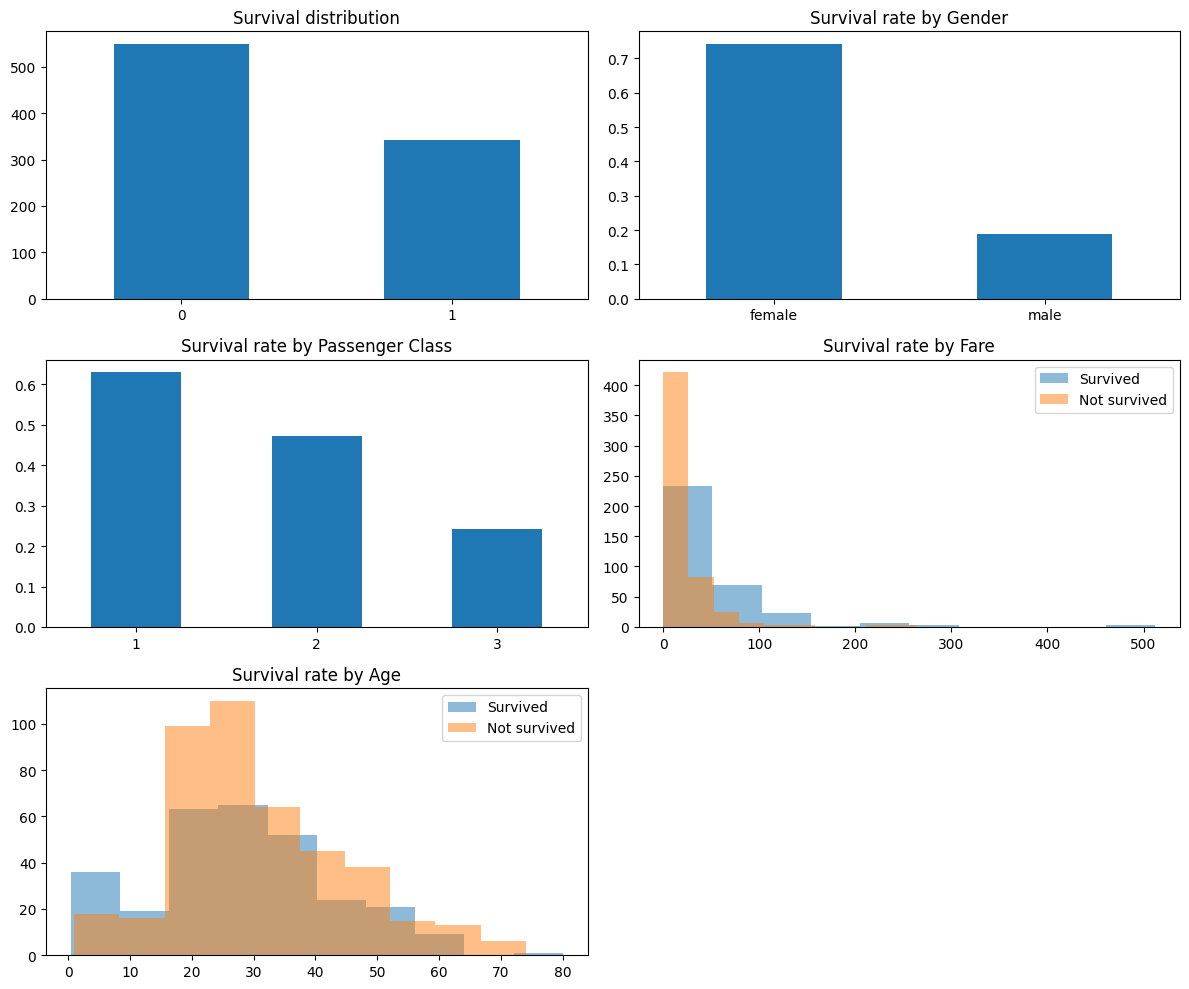

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

df['Survived'].value_counts().plot(kind='bar', ax=axes[0, 0]).set_xlabel('')
axes[0, 0].set_title('Survival distribution')
axes[0, 0].tick_params(axis='x', rotation=0)

df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0, 1]).set_xlabel('')
axes[0, 1].set_title('Survival rate by Gender')
axes[0, 1].tick_params(axis='x', rotation=0)

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1, 0]).set_xlabel('')
axes[1, 0].set_title('Survival rate by Passenger Class')
axes[1, 0].tick_params(axis='x', rotation=0)

df[df['Survived']==1]['Fare'].plot(kind='hist', alpha=0.5, ax=axes[1, 1])
df[df['Survived']==0]['Fare'].plot(kind='hist', alpha=0.5, ax=axes[1, 1]).set_ylabel('')
axes[1, 1].set_title("Survival rate by Fare")
axes[1, 1].legend(["Survived", "Not survived"])

df[df['Survived']==1]['Age'].plot(kind='hist', alpha=0.5, ax=axes[2, 0])
df[df['Survived']==0]['Age'].plot(kind='hist', alpha=0.5, ax=axes[2, 0]).set_ylabel('')
axes[2, 0].set_title("Survival rate by Age")
axes[2, 0].legend(["Survived", "Not survived"])

axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[cols]
y = df['Survived']

In [5]:
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Embarked'] = X['Embarked'].fillna('S')

In [6]:
le = LabelEncoder()

X['Sex'] = le.fit_transform(X['Sex'])
X['Embarked'] = le.fit_transform(X['Embarked'])

In [7]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [9]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print("Train:", clf.score(X_train, y_train))
print("Test:", clf.score(X_test, y_test))

Train: 0.797752808988764
Test: 0.7988826815642458


In [10]:
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

print("Train:", clf.score(X_train, y_train))
print("Test:", clf.score(X_test, y_test))

Train: 0.9789325842696629
Test: 0.8100558659217877


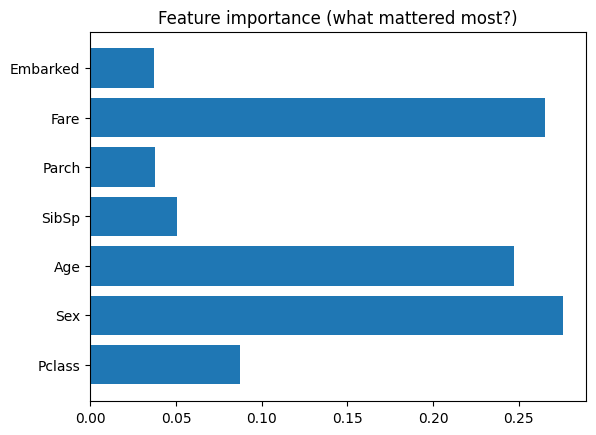

In [11]:
importances = clf.feature_importances_

plt.barh(cols, importances)
plt.title("Feature importance (what mattered most?)")
plt.show()